<a href="https://colab.research.google.com/github/ymuto0302/PJ2025/blob/main/MLP_comparison_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### scikit-learnを用いたMLP分類器の実装と性能比較
プロジェクト学習のネタ

In [2]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 43.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=9741b64fec9e85554e50f1b666e8e9b3c5d6f1ae88ab797a43d7120dfe7cd849
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


### 必要なライブラリのインポート

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
import japanize_matplotlib
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.datasets import make_classification, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

### 実験用データセットの作成

In [7]:
def create_datasets():
    """3種類の分類問題データセットを作成"""

    # データセット1: 線形分離可能な問題
    X1, y1 = make_classification(
        n_samples=1000,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=1,
        random_state=42
    )

    # データセット2: 非線形分離問題（円形）
    X2, y2 = make_circles(
        n_samples=1000,
        noise=0.1,
        factor=0.5,
        random_state=42
    )

    # データセット3: 複雑な非線形問題
    X3, y3 = make_classification(
        n_samples=1000,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=2,
        random_state=42
    )

    return (X1, y1), (X2, y2), (X3, y3)

# データセット作成
datasets = create_datasets()

### データの可視化

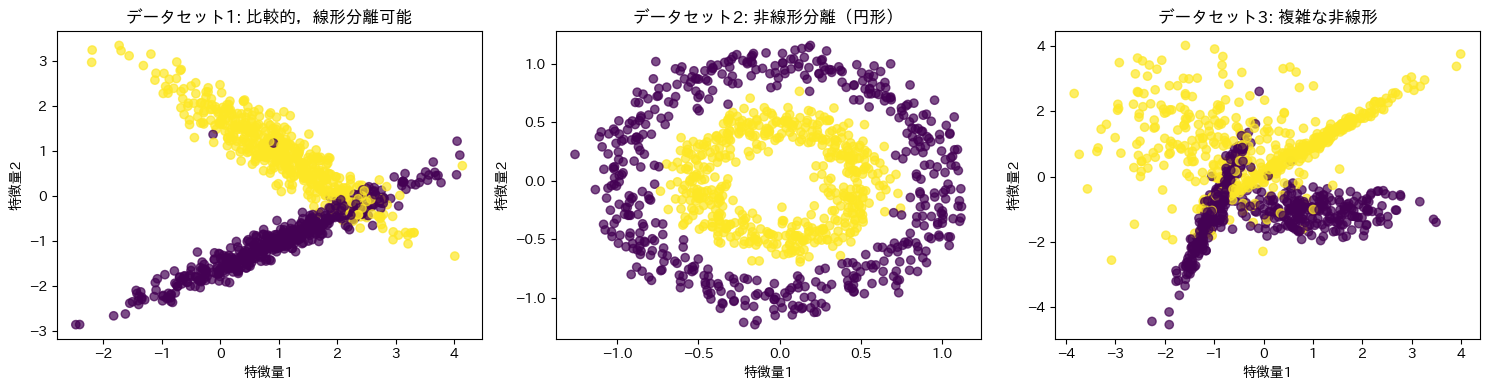

In [8]:
def visualize_datasets(datasets):
    """データセットを可視化"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    titles = ['比較的，線形分離可能', '非線形分離（円形）', '複雑な非線形']

    for i, ((X, y), title) in enumerate(zip(datasets, titles)):
        axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
        axes[i].set_title(f'データセット{i+1}: {title}')
        axes[i].set_xlabel('特徴量1')
        axes[i].set_ylabel('特徴量2')

    plt.tight_layout()
    plt.show()

visualize_datasets(datasets)

### 基本的なMLPClassifierの実装

In [9]:
def basic_mlp():
    """基本的なMLPの実装例"""

    # データセット2（非線形問題）を使用
    X, y = datasets[1]

    # データの標準化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 訓練・テストデータ分割
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42)

    # MLPClassifierの作成（デフォルト設定）
    mlp = MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=1000)

    # 学習
    mlp.fit(X_train, y_train)

    # 予測と評価
    y_pred = mlp.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"使用したアーキテクチャ: {mlp.hidden_layer_sizes}")
    print(f"使用した活性化関数: {mlp.activation}")
    print(f"学習率: {mlp.learning_rate_init}")
    print(f"テスト精度: {accuracy:.3f}")

    return mlp, X_train, X_test, y_train, y_test

# 基本例の実行
mlp, X_train, X_test, y_train, y_test = basic_mlp()

使用したアーキテクチャ: (100,)
使用した活性化関数: relu
学習率: 0.001
テスト精度: 0.990


### (参考) 決定境界の可視化

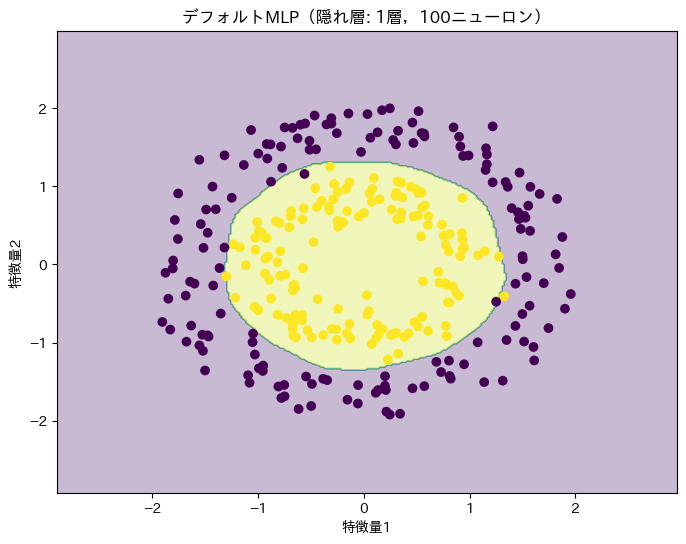

In [10]:
def plot_decision_boundary(X, y, model, title):
    """決定境界を可視化"""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
    plt.title(title)
    plt.xlabel('特徴量1')
    plt.ylabel('特徴量2')

# 基本MLPの決定境界を可視化
plt.figure(figsize=(8, 6))
plot_decision_boundary(X_test, y_test, mlp, 'デフォルトMLP（隠れ層: 1層，100ニューロン）')
plt.show()

### 異なる隠れ層構造での比較

In [11]:
def compare_hidden_layers():
    """異なる隠れ層構造での性能比較"""

    # 非線形問題（円形データ）を使用
    X, y = datasets[1]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42
    )

    # 異なる隠れ層構造
    hidden_layer_configs = [
        (3,),           # 1層: 3ニューロン
        (10,),          # 1層: 10ニューロン
        (10, 10),        # 2層: 10→10ニューロン
        (100, 50),       # 2層: 100→50ニューロン
        (100, 50, 25),   # 3層: 100→50→25ニューロン
        (200, 100, 50, 25)  # 4層: 200→100→50→25ニューロン
    ]

    results = []
    models = []

    print("=== 隠れ層構造による性能比較 ===")

    for i, hidden_layers in enumerate(hidden_layer_configs):
        print(f"\n構造 {i+1}: {hidden_layers}")

        # MLPの作成と学習
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            random_state=42,
            max_iter=1000,
            learning_rate_init=0.01
        )

        mlp.fit(X_train, y_train)

        # 評価
        train_score = mlp.score(X_train, y_train)
        test_score = mlp.score(X_test, y_test)

        results.append({
            'structure': str(hidden_layers),
            'layers': len(hidden_layers),
            'total_neurons': sum(hidden_layers),
            'train_accuracy': train_score,
            'test_accuracy': test_score
        })

        models.append((hidden_layers, mlp))

        print(f"  訓練精度: {train_score:.3f}")
        print(f"  テスト精度: {test_score:.3f}")
        print(f"  反復回数: {mlp.n_iter_}")

    return results, models, X_train, X_test, y_train, y_test

# 隠れ層比較の実行
layer_results, layer_models, X_train, X_test, y_train, y_test = compare_hidden_layers()

=== 隠れ層構造による性能比較 ===

構造 1: (3,)
  訓練精度: 0.757
  テスト精度: 0.713
  反復回数: 141

構造 2: (10,)
  訓練精度: 0.996
  テスト精度: 0.987
  反復回数: 275

構造 3: (10, 10)
  訓練精度: 0.999
  テスト精度: 0.993
  反復回数: 137

構造 4: (100, 50)
  訓練精度: 0.997
  テスト精度: 0.990
  反復回数: 37

構造 5: (100, 50, 25)
  訓練精度: 0.996
  テスト精度: 0.987
  反復回数: 20

構造 6: (200, 100, 50, 25)
  訓練精度: 0.997
  テスト精度: 0.990
  反復回数: 38


### 決定境界の可視化(モデル間の比較)

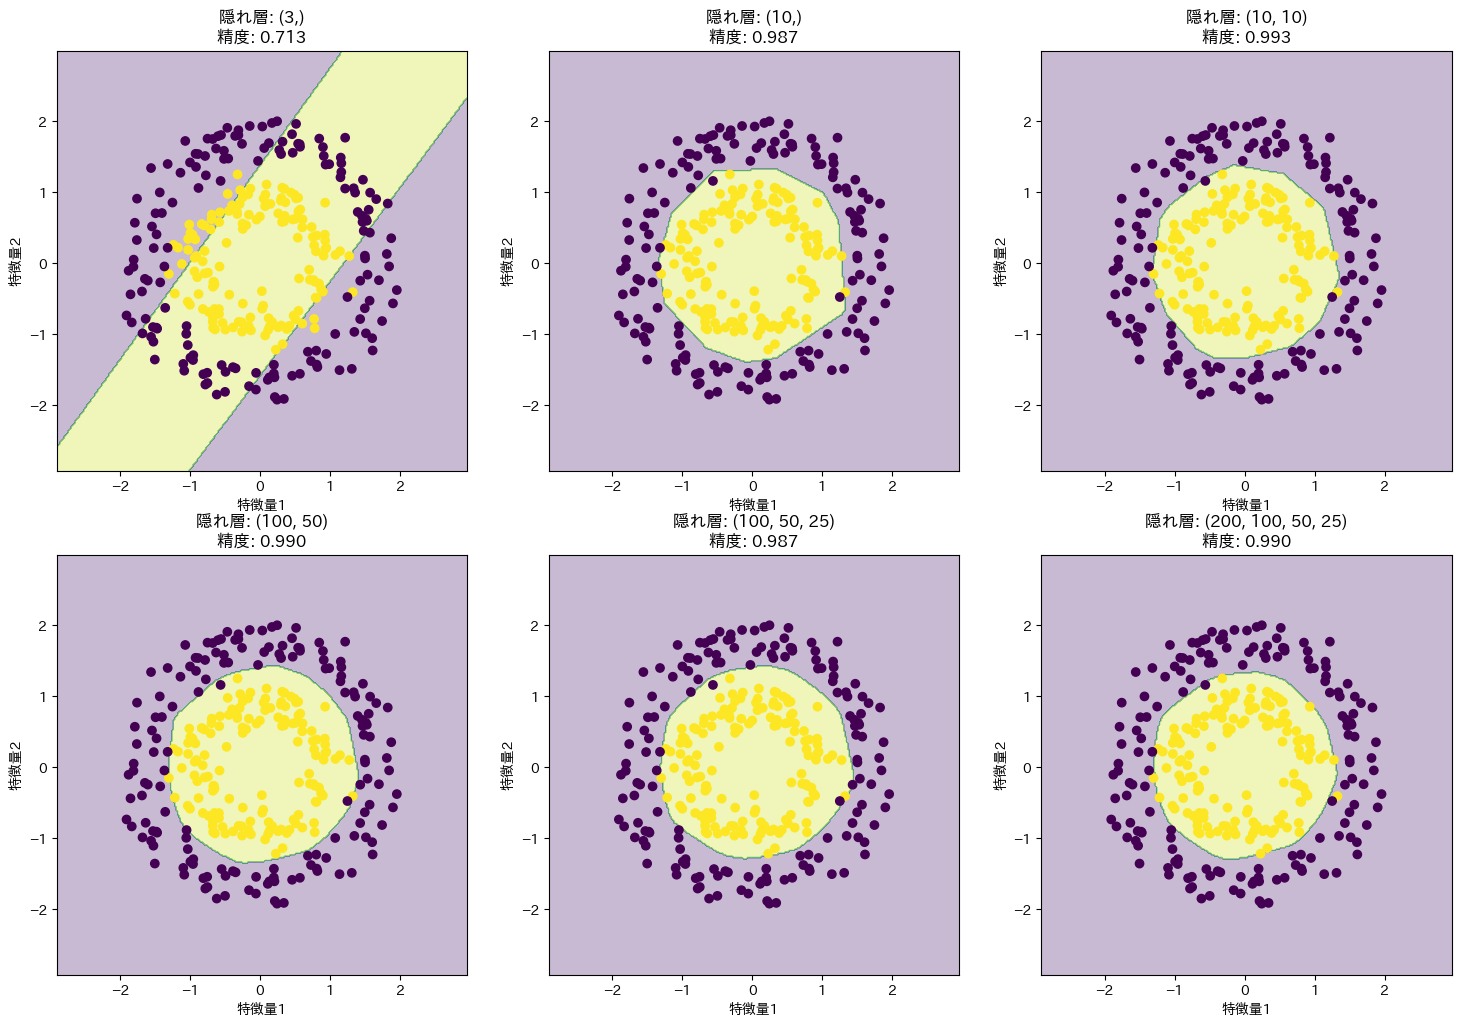

In [12]:
def visualize_layer_comparison(results, models, X_test, y_test):
    """隠れ層比較結果の可視化"""

    # 精度比較グラフ
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 決定境界の比較（選択した構造のみ）
    selected_indices = [0, 1, 2, 3, 4, 5]  # 1層、2層、3層を比較

    for idx in range(6):
        hidden_layers, model = layer_models[idx]
        ax = axes[idx // 3, idx % 3]
        plt.sca(ax)
        plot_decision_boundary(X_test, y_test, model,
                              f'隠れ層: {hidden_layers}\n精度: {results[idx]["test_accuracy"]:.3f}')

visualize_layer_comparison(layer_results, layer_models, X_test, y_test)

### 異なる学習率での比較

In [13]:
def compare_learning_rates():
    """異なる学習率での性能比較"""

    # 非線形問題を使用
    X, y = datasets[1]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42
    )

    learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]

    results = []
    loss_curves = []

    print("=== 学習率による収束性比較 ===")

    for lr in learning_rates:
        print(f"\n学習率: {lr}")

        mlp = MLPClassifier(
            hidden_layer_sizes=(100, 50),
            learning_rate_init=lr,
            random_state=42,
            max_iter=300,
            validation_fraction=0.1
        )

        try:
            mlp.fit(X_train, y_train)

            train_score = mlp.score(X_train, y_train)
            test_score = mlp.score(X_test, y_test)

            results.append({
                'learning_rate': lr,
                'train_accuracy': train_score,
                'test_accuracy': test_score,
                'iterations': mlp.n_iter_
            })

            loss_curves.append((lr, mlp.loss_curve_))

            print(f"  訓練精度: {train_score:.3f}")
            print(f"  テスト精度: {test_score:.3f}")
            print(f"  反復回数: {mlp.n_iter_}")

        except Exception as e:
            print(f"  エラー: {e}")
            results.append({
                'learning_rate': lr,
                'train_accuracy': 0,
                'test_accuracy': 0,
                'iterations': 1000
            })

    return results, loss_curves, X_train, X_test, y_train, y_test

# 学習率比較の実行
lr_results, loss_curves, X_train_lr, X_test_lr, y_train_lr, y_test_lr = compare_learning_rates()

=== 学習率による収束性比較 ===

学習率: 0.001
  訓練精度: 0.999
  テスト精度: 0.987
  反復回数: 191

学習率: 0.01
  訓練精度: 0.997
  テスト精度: 0.990
  反復回数: 37

学習率: 0.1
  訓練精度: 0.999
  テスト精度: 0.993
  反復回数: 52

学習率: 0.5
  訓練精度: 0.999
  テスト精度: 0.980
  反復回数: 65

学習率: 1.0
  訓練精度: 0.996
  テスト精度: 0.977
  反復回数: 37

学習率: 2.0
  訓練精度: 0.980
  テスト精度: 0.953
  反復回数: 28


### 学習率とテスト精度の関係を可視化

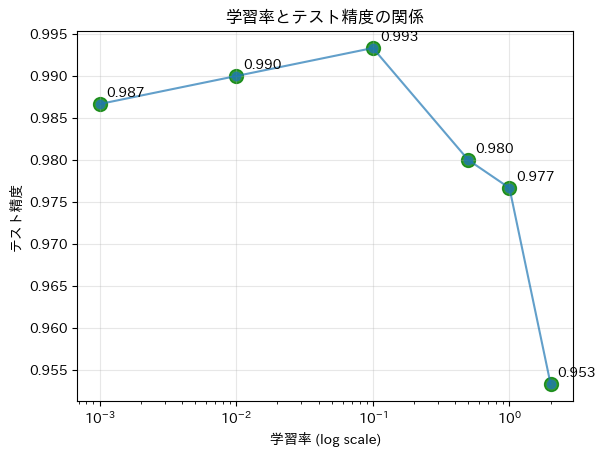

In [14]:
def visualize_learning_rate_comparison(results, loss_curves):
    """学習率比較結果の可視化"""

    fig, ax = plt.subplots() #1, figsize=(15, 12))

    # 学習率vs精度
    learning_rates = [r['learning_rate'] for r in results]
    test_accs = [r['test_accuracy'] for r in results]

    ax.semilogx(learning_rates, test_accs, 'o-', alpha=0.7)
    for i, (lr, acc) in enumerate(zip(learning_rates, test_accs)):
        ax.scatter(lr, acc, c='green', s=100, alpha=0.8)
        ax.annotate(f'{acc:.3f}', (lr, acc), xytext=(5, 5),
                           textcoords='offset points', fontsize=10)

    ax.set_xlabel('学習率 (log scale)')
    ax.set_ylabel('テスト精度')
    ax.set_title('学習率とテスト精度の関係')
    ax.grid(True, alpha=0.3)

    # plt.tight_layout()
    plt.show()

visualize_learning_rate_comparison(lr_results, loss_curves)

### グリッドサーチによる最適パラメータ探索


=== 比較的，線形分離可能 データセットでの最適化 ===
最適パラメータ: {'activation': 'relu', 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001}
最適CV精度: 0.957
テスト精度: 0.933


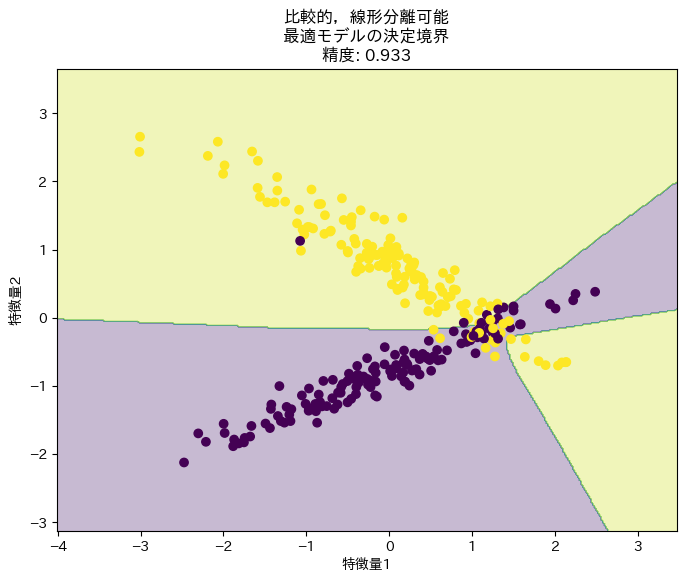


=== 非線形（円形） データセットでの最適化 ===
最適パラメータ: {'activation': 'relu', 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}
最適CV精度: 0.999
テスト精度: 0.990


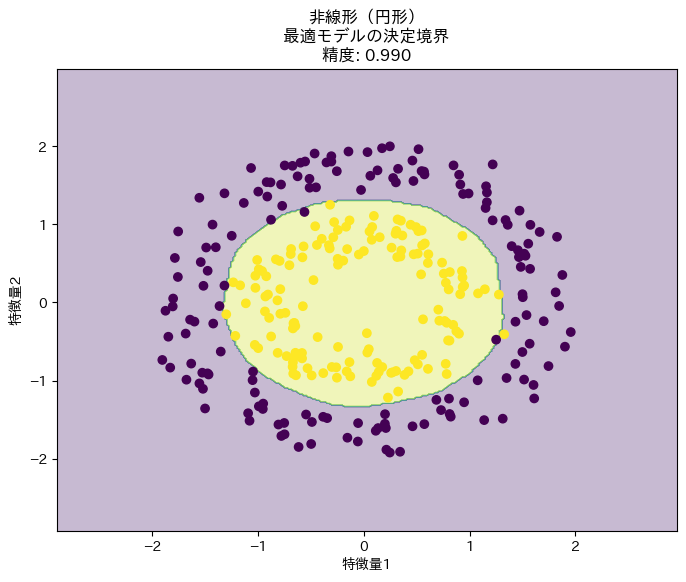


=== 複雑な非線形 データセットでの最適化 ===
最適パラメータ: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
最適CV精度: 0.926
テスト精度: 0.920


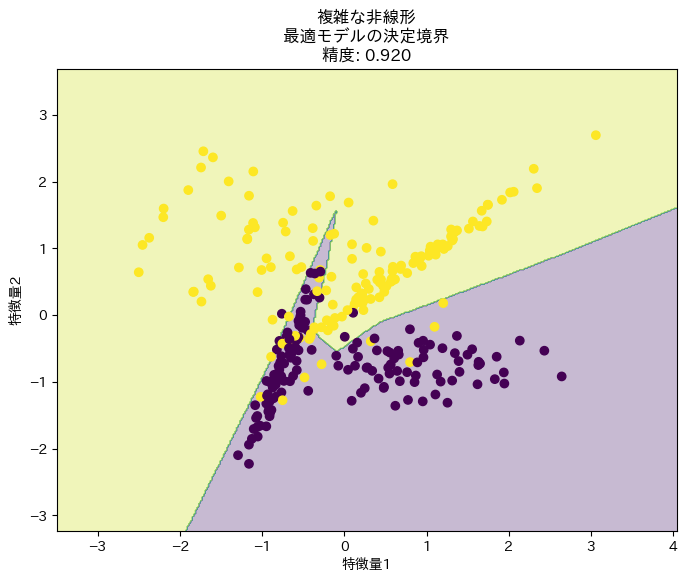

In [15]:
def comprehensive_optimization():
    """グリッドサーチによる最適パラメータ探索"""

    from sklearn.model_selection import GridSearchCV

    # 3つのデータセット全てで実験
    dataset_names = ['比較的，線形分離可能', '非線形（円形）', '複雑な非線形']

    for i, ((X, y), name) in enumerate(zip(datasets, dataset_names)):
        print(f"\n=== {name} データセットでの最適化 ===")

        # データ前処理
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.3, random_state=42
        )

        # パラメータグリッド
        param_grid = {
            'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
            'learning_rate_init': [0.001, 0.01, 0.1],
            'activation': ['relu', 'tanh']
        }

        # グリッドサーチ
        mlp = MLPClassifier(random_state=42, max_iter=1000)
        grid_search = GridSearchCV(mlp, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        # 結果表示
        print(f"最適パラメータ: {grid_search.best_params_}")
        print(f"最適CV精度: {grid_search.best_score_:.3f}")

        # テストデータでの評価
        best_model = grid_search.best_estimator_
        test_score = best_model.score(X_test, y_test)
        print(f"テスト精度: {test_score:.3f}")

        # 決定境界の可視化
        plt.figure(figsize=(8, 6))
        plot_decision_boundary(X_test, y_test, best_model,
                              f'{name}\n最適モデルの決定境界\n精度: {test_score:.3f}')
        plt.show()

comprehensive_optimization()
